# S1.1: frozen real-development QC

Этот notebook **не запускает регистрацию и не строит парные анатомические измерения**. Он читает batch-артефакты шести заранее выбранных Learn2Reg LungCT без expert landmarks, проверяет provenance и визуализирует pre-expert gate.

Даже `6/6 PASS` здесь означает только разрешение однократного независимого Gate 1L. Все поля имеют disposition `real_development_diagnostic_ONLY`, `measurement_eligible=false`; Gate 1B для мягких тканей этим notebook не проверяется.

In [1]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from breathgeom.io.pairs import read_pair_manifest
from breathgeom.measure.wall import load_ras

candidate = Path.cwd().resolve()
REPO_ROOT = next(
    (path for path in (candidate, *candidate.parents) if (path / "pyproject.toml").is_file()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Не найден корень репозитория")

RESULTS = REPO_ROOT / "results/sliding_s11_real_development_v1"
DIAGNOSTICS = REPO_ROOT / "results/sliding_s11_real_development_v1_diagnostics"
manifest_path = RESULTS / "manifest.json"
summary_path = RESULTS / "summary.csv"
if not manifest_path.is_file() or not summary_path.is_file():
    raise RuntimeError(
        "Нет real-development batch. Выполните: breathgeom registration sliding-real-development"
    )

diagnostic_manifest_path = DIAGNOSTICS / "manifest.json"
variant_summary_path = DIAGNOSTICS / "variant_summary.csv"
if not diagnostic_manifest_path.is_file() or not variant_summary_path.is_file():
    raise RuntimeError("Нет воспроизводимого post-hoc failure diagnosis batch")

manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
diagnostic_manifest = json.loads(diagnostic_manifest_path.read_text(encoding="utf-8"))
summary = pd.read_csv(summary_path)
variant_summary = pd.read_csv(variant_summary_path)
gate_config_path = REPO_ROOT / "configs/sliding_s11_real_development_gate.json"
s1_config_path = REPO_ROOT / "configs/sliding_s1_v1.json"
gate_config = json.loads(gate_config_path.read_text(encoding="utf-8"))
s1_config = json.loads(s1_config_path.read_text(encoding="utf-8"))
thresholds = gate_config["thresholds"]
summary

,gate_version,dataset_id,subject_id,s1_version,coordinate_basis,transform_direction,shape,spacing_mm,measurement_eligible,expert_landmarks_loaded,...,tangential_valid_voxel_count,tangential_function_evaluations,tangential_optimizer_success,lung_runtime_s,body_runtime_s,torch_version,convexadam_version,device,gate_pass,gate_reasons
0,s1.1-real-development-v1,learn2reg_lungct,LungCT_0004,s1.1,local-zero-origin-RAS+_mm,fixed-expiration_to_moving-inspiration,192x192x208,1.75x1.25x1.75,False,False,...,766353,438,True,32.739667,5.202522,2.5.1+cu118,0.2.0,NVIDIA GeForce GTX 1070,False,keypoint_tre_mean;keypoint_tre_p95;keypoint_tr...
1,s1.1-real-development-v1,learn2reg_lungct,LungCT_0005,s1.1,local-zero-origin-RAS+_mm,fixed-expiration_to_moving-inspiration,192x192x208,1.75x1.25x1.75,False,False,...,1086183,306,True,34.256706,5.367183,2.5.1+cu118,0.2.0,NVIDIA GeForce GTX 1070,False,lung_fov_dice;lung_fov_surface_p95;keypoint_tr...
2,s1.1-real-development-v1,learn2reg_lungct,LungCT_0008,s1.1,local-zero-origin-RAS+_mm,fixed-expiration_to_moving-inspiration,192x192x208,1.75x1.25x1.75,False,False,...,820121,502,True,34.560099,4.814350,2.5.1+cu118,0.2.0,NVIDIA GeForce GTX 1070,False,lung_fov_surface_p95;keypoint_tre_mean;keypoin...
3,s1.1-real-development-v1,learn2reg_lungct,LungCT_0015,s1.1,local-zero-origin-RAS+_mm,fixed-expiration_to_moving-inspiration,192x192x208,1.75x1.25x1.75,False,False,...,797230,421,True,34.224893,4.849829,2.5.1+cu118,0.2.0,NVIDIA GeForce GTX 1070,False,lung_fov_surface_p95;keypoint_tre_mean;keypoin...
4,s1.1-real-development-v1,learn2reg_lungct,LungCT_0022,s1.1,local-zero-origin-RAS+_mm,fixed-expiration_to_moving-inspiration,192x192x208,1.75x1.25x1.75,False,False,...,1239913,432,True,34.814197,5.041056,2.5.1+cu118,0.2.0,NVIDIA GeForce GTX 1070,False,lung_fov_surface_p95;keypoint_tre_mean;keypoin...


## Provenance и запрет на measurement use

Checksums проверяются до интерпретации таблиц. Notebook также проверяет, что expert landmarks не использовались и ни одно поле не объявлено измерительным.

In [2]:
def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest().upper()


checks = {
    "pair manifest": sha256(REPO_ROOT / "data/interim/respiratory_pairs.local.csv")
    == manifest["pair_manifest"]["sha256"],
    "S1.1 config": sha256(s1_config_path) == manifest["s1_config"]["sha256"],
    "gate config": sha256(gate_config_path) == manifest["gate_config"]["sha256"],
    "summary": sha256(summary_path) == manifest["summary_sha256"],
    "fields": all(
        sha256(RESULTS / relative) == digest
        for relative, digest in manifest["field_sha256"].items()
    ),
    "diagnostic input batch": sha256(manifest_path)
    == diagnostic_manifest["input_batch_manifest"]["sha256"],
    "diagnostic summary": sha256(variant_summary_path) == diagnostic_manifest["summary_sha256"],
    "diagnostic expert unused": diagnostic_manifest["expert_landmarks_used"] is False,
    "expert landmarks unused": manifest["selection"]["expert_landmarks_used"] is False,
    "batch not measurement eligible": manifest["measurement_eligible"] is False,
    "rows not measurement eligible": not summary["measurement_eligible"]
    .map(lambda value: str(value).lower() == "true")
    .any(),
}
provenance_table = pd.DataFrame({"check": list(checks), "pass": list(checks.values())})
display(provenance_table)
if not all(checks.values()):
    raise RuntimeError("Нарушена целостность или disposition batch-артефактов")

display(
    pd.DataFrame(
        {
            "field": [
                "code_version",
                "gate_version",
                "s1_version",
                "completed",
                "pass_count",
                "all_pass",
            ],
            "value": [
                manifest["code_version"],
                manifest["gate_version"],
                manifest["s1_version"],
                manifest["subject_count_completed"],
                manifest["pass_count"],
                manifest["all_pass"],
            ],
        }
    )
)

,check,pass
0,pair manifest,True
1,S1.1 config,True
2,gate config,True
3,summary,True
4,fields,True
5,diagnostic input batch,True
6,diagnostic summary,True
7,diagnostic expert unused,True
8,expert landmarks unused,True
9,batch not measurement eligible,True


,field,value
0,code_version,ea8113b5163141081eab2b0b554e77e38646daf2
1,gate_version,s1.1-real-development-v1
2,s1_version,s1.1
3,completed,5
4,pass_count,0
5,all_pass,False


## Замороженный gate по субъектам

Единица анализа — субъект. Body surface метрики выводятся ниже отдельно, но намеренно не входят в PASS: threshold-body mask не является независимой разметкой кожи, жира, мышц или рёбер.

In [3]:
gate_matrix = pd.DataFrame(
    {
        "lung Dice": summary["lung_fov_dice_after"] >= thresholds["lung_fov_dice_min"],
        "lung surface": summary["lung_fov_surface_p95_after_mm"]
        <= thresholds["lung_fov_surface_p95_max_mm"],
        "fixed coverage": summary["lung_fov_fixed_surface_coverage_after"]
        >= thresholds["lung_surface_coverage_min"],
        "moving coverage": summary["lung_fov_moving_surface_coverage_after"]
        >= thresholds["lung_surface_coverage_min"],
        "common FOV": summary["common_fov_fraction_after"] >= thresholds["common_fov_fraction_min"],
        "keypoint mean": summary["keypoint_tre_after_mean_mm"]
        <= thresholds["keypoint_tre_after_mean_max_mm"],
        "keypoint p95": summary["keypoint_tre_after_p95_mm"]
        <= thresholds["keypoint_tre_after_p95_max_mm"],
        "keypoint improvement": summary["keypoint_tre_improvement_fraction"]
        >= thresholds["keypoint_tre_improvement_fraction_min"],
        "lung topology": (summary["lung_jacobian_p01"] >= thresholds["lung_jacobian_p01_min"])
        & (
            summary["lung_nonpositive_jacobian_fraction"]
            <= thresholds["nonpositive_jacobian_fraction_max"]
        ),
        "body topology": (summary["body_jacobian_p01"] >= thresholds["body_jacobian_p01_min"])
        & (
            summary["body_nonpositive_jacobian_fraction"]
            <= thresholds["nonpositive_jacobian_fraction_max"]
        ),
        "normal contact": summary["interface_normal_mismatch_p95_mm"]
        <= thresholds["interface_normal_mismatch_p95_max_mm"],
        "coefficients": summary["coefficient_abs_fraction_max"]
        <= thresholds["coefficient_abs_fraction_max"],
        "objective": summary["tangential_objective_relative_improvement"]
        >= thresholds["tangential_objective_relative_improvement_min"],
        "optimizer": summary["tangential_optimizer_success"].map(
            lambda value: str(value).lower() == "true"
        ),
        "tangent fit support": summary["tangential_valid_voxel_count"]
        >= s1_config["tangential_model"]["minimum_valid_voxels"],
        "lung displacement": summary["lung_displacement_p99_mm"]
        <= thresholds["lung_displacement_p99_max_mm"],
        "body displacement": summary["body_displacement_p99_mm"]
        <= thresholds["body_displacement_p99_max_mm"],
        "interface support": summary["interface_core_voxel_count"]
        >= thresholds["interface_core_voxel_count_min"],
    }
)
gate_matrix.index = summary["subject_id"]
display(
    gate_matrix.style.map(lambda value: "background:#b7e4c7" if value else "background:#ffadad")
)
display(summary[["subject_id", "gate_pass", "gate_reasons"]])
gate_pass_values = summary["gate_pass"].map(lambda value: str(value).lower() == "true")
assert np.array_equal(gate_matrix.all(axis=1).to_numpy(), gate_pass_values.to_numpy())

,lung Dice,lung surface,fixed coverage,moving coverage,common FOV,keypoint mean,keypoint p95,keypoint improvement,lung topology,body topology,normal contact,coefficients,objective,optimizer,tangent fit support,lung displacement,body displacement,interface support
subject_id,,,,,,,,,,,,,,,,,,
LungCT_0004,True,True,True,True,True,False,False,False,False,True,True,True,True,True,True,True,True,True
LungCT_0005,False,False,True,True,True,False,False,False,False,True,True,False,True,True,True,True,True,True
LungCT_0008,True,False,True,True,True,False,False,False,False,True,True,True,True,True,True,True,True,True
LungCT_0015,True,False,True,True,True,False,False,False,False,True,True,True,True,True,True,True,True,True
LungCT_0022,True,False,True,True,True,False,False,False,False,True,True,True,True,True,True,True,True,True


,subject_id,gate_pass,gate_reasons
0,LungCT_0004,False,keypoint_tre_mean;keypoint_tre_p95;keypoint_tr...
1,LungCT_0005,False,lung_fov_dice;lung_fov_surface_p95;keypoint_tr...
2,LungCT_0008,False,lung_fov_surface_p95;keypoint_tre_mean;keypoin...
3,LungCT_0015,False,lung_fov_surface_p95;keypoint_tre_mean;keypoin...
4,LungCT_0022,False,lung_fov_surface_p95;keypoint_tre_mean;keypoin...


## Mask/keypoint, topology и стоимость

Графики показывают независимые оси отказа. Улучшение image-derived keypoints полезно только для development; оно не заменяет expert TRE.

Runtime-панель содержит только отдельно записанные ConvexAdam и body Demons. В первой реализации время Powell tangent-fit не инструментировано; поэтому суммы столбцов нельзя считать полным wall-clock. Это известный дефект provenance, который должен быть исправлен без изменения frozen алгоритма.

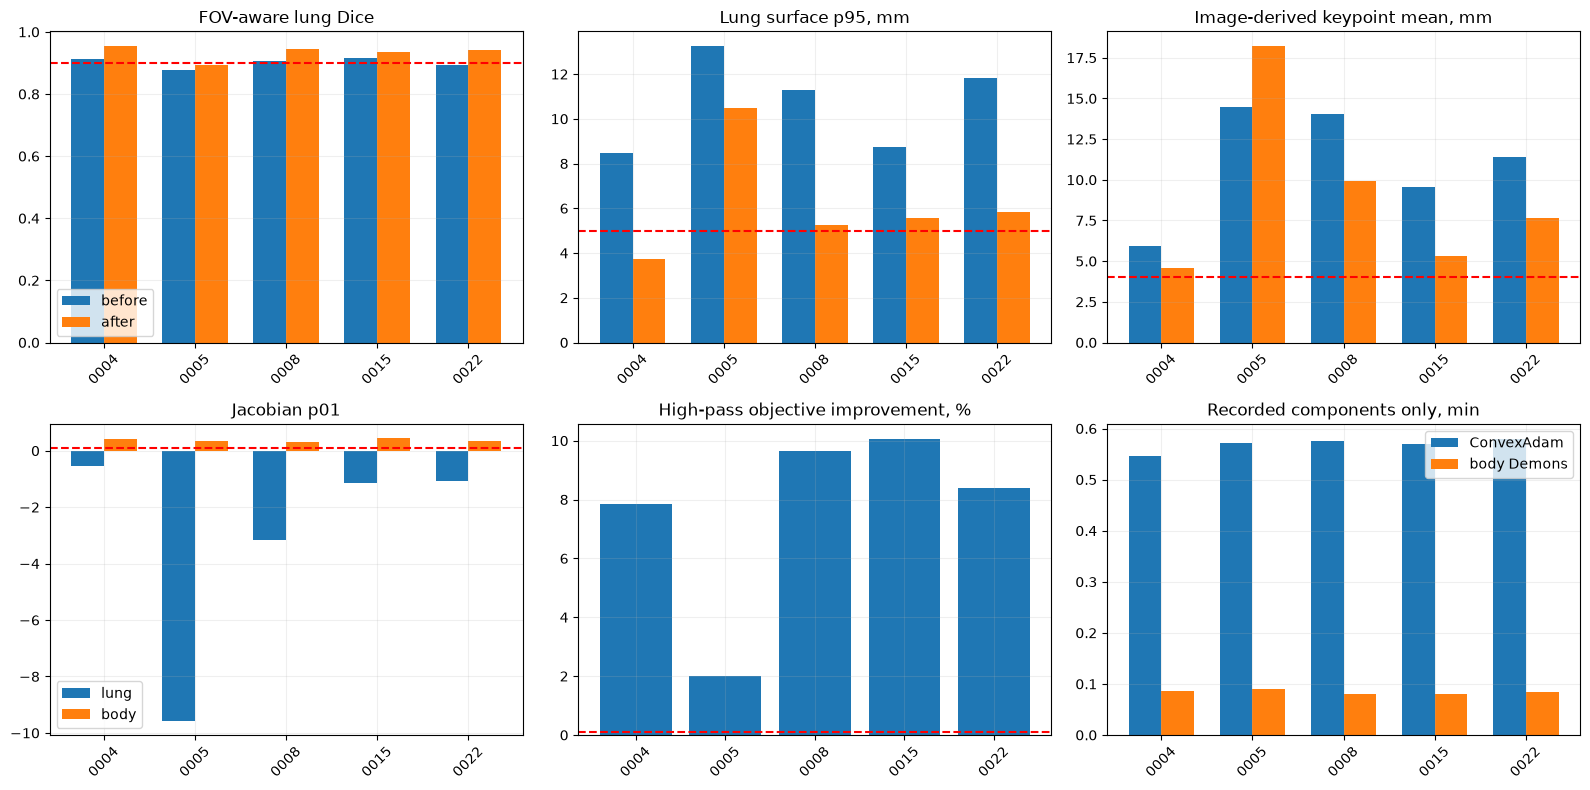

,subject_id,body_fov_dice_after,body_fov_surface_p95_after_mm,fixed_lung_outside_threshold_body_voxels,moving_lung_outside_threshold_body_voxels
0,LungCT_0004,0.971005,38.560018,8621,0
1,LungCT_0005,0.963459,54.023722,22005,0
2,LungCT_0008,0.960078,34.468283,40280,0
3,LungCT_0015,0.957187,47.432715,58505,0
4,LungCT_0022,0.939443,68.830862,150588,0


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
x = np.arange(len(summary))
labels = summary["subject_id"].str.replace("LungCT_", "")

axes[0, 0].bar(x - 0.18, summary["lung_fov_dice_before"], 0.36, label="before")
axes[0, 0].bar(x + 0.18, summary["lung_fov_dice_after"], 0.36, label="after")
axes[0, 0].axhline(thresholds["lung_fov_dice_min"], color="red", ls="--")
axes[0, 0].set_title("FOV-aware lung Dice")
axes[0, 0].legend()

axes[0, 1].bar(x - 0.18, summary["lung_fov_surface_p95_before_mm"], 0.36, label="before")
axes[0, 1].bar(x + 0.18, summary["lung_fov_surface_p95_after_mm"], 0.36, label="after")
axes[0, 1].axhline(thresholds["lung_fov_surface_p95_max_mm"], color="red", ls="--")
axes[0, 1].set_title("Lung surface p95, mm")

axes[0, 2].bar(x - 0.18, summary["keypoint_tre_before_mean_mm"], 0.36, label="before")
axes[0, 2].bar(x + 0.18, summary["keypoint_tre_after_mean_mm"], 0.36, label="after")
axes[0, 2].axhline(thresholds["keypoint_tre_after_mean_max_mm"], color="red", ls="--")
axes[0, 2].set_title("Image-derived keypoint mean, mm")

axes[1, 0].bar(x - 0.18, summary["lung_jacobian_p01"], 0.36, label="lung")
axes[1, 0].bar(x + 0.18, summary["body_jacobian_p01"], 0.36, label="body")
axes[1, 0].axhline(0.1, color="red", ls="--")
axes[1, 0].set_title("Jacobian p01")
axes[1, 0].legend()

axes[1, 1].bar(x, 100 * summary["tangential_objective_relative_improvement"])
axes[1, 1].axhline(
    100 * thresholds["tangential_objective_relative_improvement_min"], color="red", ls="--"
)
axes[1, 1].set_title("High-pass objective improvement, %")

axes[1, 2].bar(x - 0.18, summary["lung_runtime_s"] / 60, 0.36, label="ConvexAdam")
axes[1, 2].bar(x + 0.18, summary["body_runtime_s"] / 60, 0.36, label="body Demons")
axes[1, 2].set_title("Recorded components only, min")
axes[1, 2].legend()

for axis in axes.flat:
    axis.set_xticks(x, labels, rotation=45)
    axis.grid(alpha=0.2)
fig.tight_layout()
plt.show()

display(
    summary[
        [
            "subject_id",
            "body_fov_dice_after",
            "body_fov_surface_p95_after_mm",
            "fixed_lung_outside_threshold_body_voxels",
            "moving_lung_outside_threshold_body_voxels",
        ]
    ]
)

## Low-rank coefficients

Попадание коэффициента близко к ±12 мм означало бы, что six-mode prior просит движение вне замороженного диапазона. Небольшие коэффициенты сами по себе не доказывают анатомическую правильность.

,rotation_x,rotation_y,rotation_z,projected_x,projected_y,projected_z
subject_id,,,,,,
LungCT_0004,0.242,-0.663,1.092,-2.038,2.356,2.000
LungCT_0005,8.981,11.972,11.972,11.972,-3.016,10.593
LungCT_0008,0.191,-1.755,0.286,2.511,0.615,-4.404
LungCT_0015,2.071,-0.191,2.407,-0.925,-0.564,-8.058
LungCT_0022,2.322,-2.224,-1.283,3.791,4.625,5.617


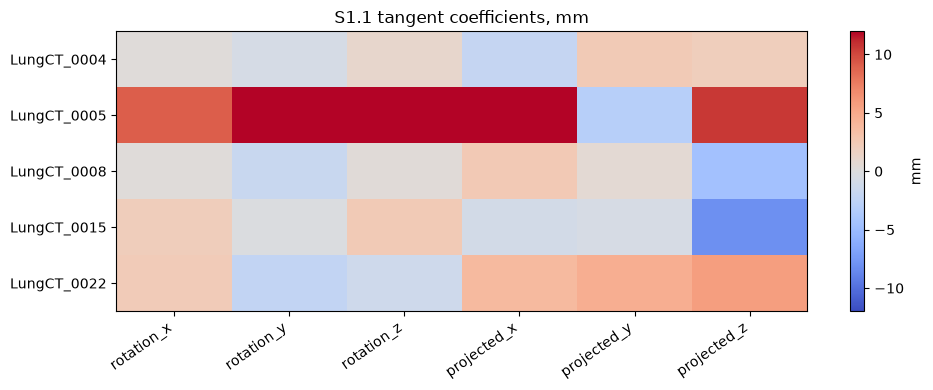

In [5]:
mode_names = summary.loc[0, "tangential_mode_names"].split(";")
coefficient_matrix = np.vstack(
    [np.fromstring(value, sep=";") for value in summary["tangential_coefficients_mm"]]
)
coefficient_table = pd.DataFrame(
    coefficient_matrix, index=summary["subject_id"], columns=mode_names
)
display(coefficient_table.round(3))

limit = max(1.0, float(np.abs(coefficient_matrix).max()))
fig, axis = plt.subplots(figsize=(10, 4))
image = axis.imshow(coefficient_matrix, cmap="coolwarm", vmin=-limit, vmax=limit, aspect="auto")
axis.set_xticks(np.arange(len(mode_names)), mode_names, rotation=35, ha="right")
axis.set_yticks(np.arange(len(summary)), summary["subject_id"])
axis.set_title("S1.1 tangent coefficients, mm")
fig.colorbar(image, ax=axis, label="mm")
fig.tight_layout()
plt.show()

## Где ломается S1.1

Это отдельный post-hoc batch без expert landmarks и без подбора параметров. Для каждого завершённого субъекта одинаковые QC-метрики пересчитаны на трёх полях: исходный S1.1 ConvexAdam, его чистая normal projection и итоговый six-mode S1.1. `LungCT_0029` отсутствует, потому что frozen optimizer остановил его до создания поля.

,keypoint_tre_mean_mm,lung_fov_surface_p95_mm,lung_jacobian_p01,lung_nonpositive_jacobian_fraction
variant,,,,
initial_convexadam,1.6977,5.2500,0.2399,0.0019
normal_projection,10.0918,6.0725,-0.8540,0.0326
final_s1.1,7.6356,5.5790,-1.1559,0.0394


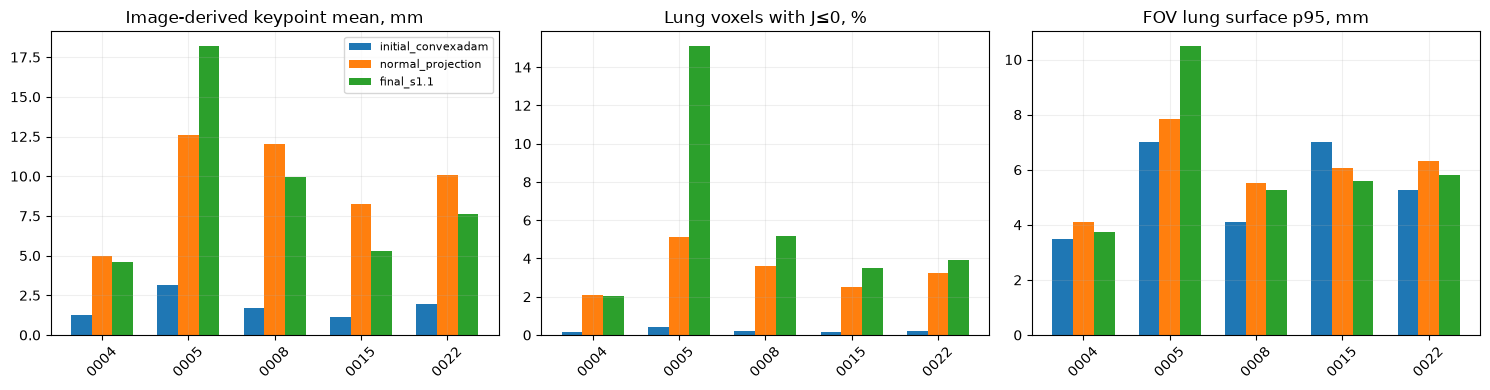

**Причинный вывод:** основной скачок ошибки и folding возникает уже при удалении исходной tangential residual (`initial → normal projection`). Six-mode fit не восстанавливает потерянное локальное движение; у части случаев он дополнительно ухудшает topology. Хороший mask Dice поэтому не является доказательством корректного correspondence field.

In [6]:
variant_order = ["initial_convexadam", "normal_projection", "final_s1.1"]
variant_medians = (
    variant_summary.groupby("variant")[
        [
            "keypoint_tre_mean_mm",
            "lung_fov_surface_p95_mm",
            "lung_jacobian_p01",
            "lung_nonpositive_jacobian_fraction",
        ]
    ]
    .median()
    .reindex(variant_order)
)
display(variant_medians.round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for variant_index, variant in enumerate(variant_order):
    group = variant_summary[variant_summary["variant"] == variant]
    positions = np.arange(len(group)) + 0.24 * (variant_index - 1)
    axes[0].bar(positions, group["keypoint_tre_mean_mm"], 0.24, label=variant)
    axes[1].bar(positions, 100 * group["lung_nonpositive_jacobian_fraction"], 0.24)
    axes[2].bar(positions, group["lung_fov_surface_p95_mm"], 0.24)

labels = variant_summary[variant_summary["variant"] == variant_order[0]]["subject_id"]
for axis in axes:
    axis.set_xticks(np.arange(len(labels)), labels.str.replace("LungCT_", ""), rotation=45)
    axis.grid(alpha=0.2)
axes[0].set_title("Image-derived keypoint mean, mm")
axes[0].legend(fontsize=8)
axes[1].set_title("Lung voxels with J≤0, %")
axes[2].set_title("FOV lung surface p95, mm")
fig.tight_layout()
plt.show()

display(
    Markdown(
        "**Причинный вывод:** основной скачок ошибки и folding возникает уже при удалении "
        "исходной tangential residual (`initial → normal projection`). Six-mode fit не "
        "восстанавливает потерянное локальное движение; у части случаев он дополнительно "
        "ухудшает topology. Хороший mask Dice поэтому не является доказательством "
        "корректного correspondence field."
    )
)

## Пространственный QC полей

Для каждого субъекта показан axial-срез с максимальной площадью supplied lung mask: CT, модуль исходного ConvexAdam lung-field, модуль итогового S1.1 lung-field и величина внесённой low-rank поправки. Это диагностическая визуализация, не карта изменения формы или толщины.

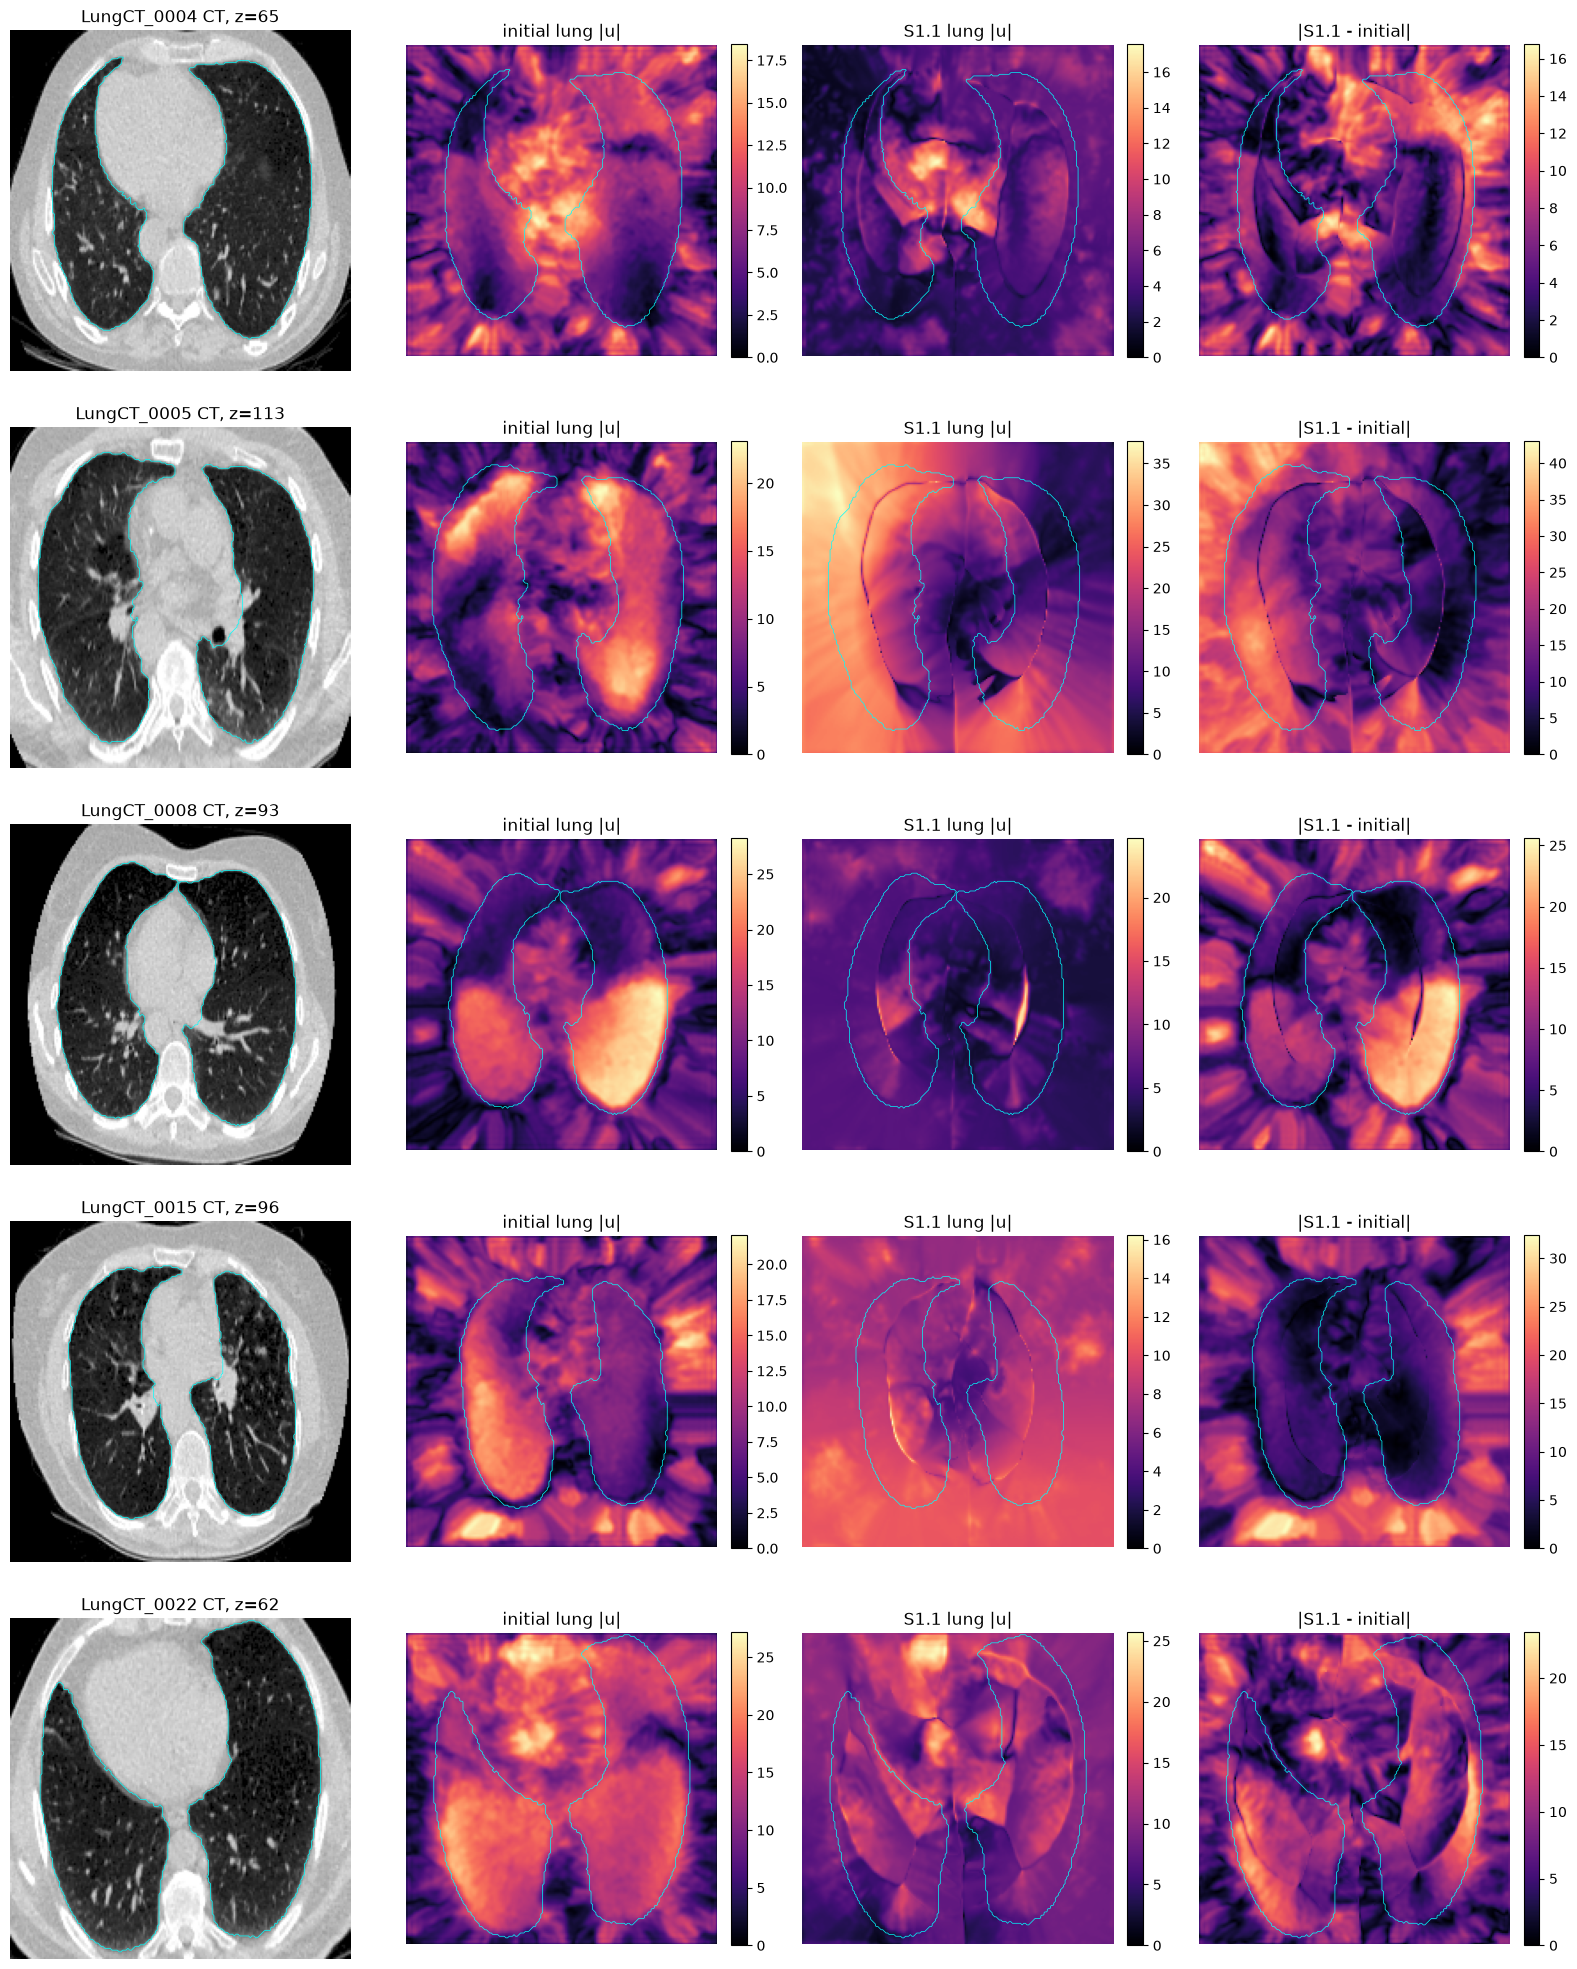

In [7]:
pair_manifest = REPO_ROOT / "data/interim/respiratory_pairs.local.csv"
pairs = {row.subject_id: row for row in read_pair_manifest(pair_manifest)}

fig, axes = plt.subplots(len(summary), 4, figsize=(16, 4 * len(summary)))
for row_index, record in summary.iterrows():
    subject = record["subject_id"]
    pair = pairs[subject]
    fixed, _ = load_ras(Path(pair.fixed_image))
    fixed_lung, _ = load_ras(Path(pair.fixed_mask))
    fixed_lung = fixed_lung > 0
    z_index = int(np.argmax(fixed_lung.sum(axis=(0, 1))))
    field_path = RESULTS / next(
        relative for relative in manifest["field_sha256"] if subject in relative
    )
    with np.load(field_path) as artifact:
        initial = np.linalg.norm(artifact["initial_lung_displacement_mm"], axis=-1)
        final = np.linalg.norm(artifact["lung_displacement_mm"], axis=-1)
        correction = np.linalg.norm(
            artifact["lung_displacement_mm"] - artifact["initial_lung_displacement_mm"],
            axis=-1,
        )
    panels = [
        fixed[:, :, z_index],
        initial[:, :, z_index],
        final[:, :, z_index],
        correction[:, :, z_index],
    ]
    titles = [f"{subject} CT, z={z_index}", "initial lung |u|", "S1.1 lung |u|", "|S1.1 - initial|"]
    for column, (values, title) in enumerate(zip(panels, titles, strict=True)):
        axis = axes[row_index, column]
        if column == 0:
            axis.imshow(values.T, cmap="gray", vmin=-1000, vmax=300, origin="lower")
        else:
            shown = axis.imshow(values.T, cmap="magma", vmin=0, origin="lower")
            fig.colorbar(shown, ax=axis, fraction=0.046, pad=0.04)
        axis.contour(fixed_lung[:, :, z_index].T, levels=[0.5], colors="cyan", linewidths=0.5)
        axis.set_title(title)
        axis.axis("off")
fig.tight_layout()
plt.show()

## Решение о следующем шаге

In [8]:
if manifest["all_pass"]:
    verdict = (
        "**PRE-EXPERT PASS: 6/6.** Разрешён один frozen 13-case Gate 1L без изменения "
        "S1.1. Парные карты и Gate 1B всё ещё запрещены."
    )
else:
    failed = summary.loc[~gate_pass_values, ["subject_id", "gate_reasons"]]
    reason_lines = [
        f"- {row.subject_id}: {row.gate_reasons}" for row in failed.itertuples(index=False)
    ]
    reason_lines.extend(f"- computational failure: {value}" for value in manifest["failures"])
    verdict = (
        f"**PRE-EXPERT FAIL: {manifest['pass_count']}/{manifest['subject_count_expected']}.** "
        "Expert Gate 1L остаётся закрыт. Следующий кандидат должен называться S1.2 и "
        "заново пройти synthetic gate. Причины:\n\n" + "\n".join(reason_lines)
    )
display(Markdown(verdict))

**PRE-EXPERT FAIL: 0/6.** Expert Gate 1L остаётся закрыт. Следующий кандидат должен называться S1.2 и заново пройти synthetic gate. Причины:

- LungCT_0004: keypoint_tre_mean;keypoint_tre_p95;keypoint_tre_improvement;lung_jacobian_p01;lung_folding
- LungCT_0005: lung_fov_dice;lung_fov_surface_p95;keypoint_tre_mean;keypoint_tre_p95;keypoint_tre_improvement;lung_jacobian_p01;lung_folding;tangential_coefficient_bound
- LungCT_0008: lung_fov_surface_p95;keypoint_tre_mean;keypoint_tre_p95;keypoint_tre_improvement;lung_jacobian_p01;lung_folding
- LungCT_0015: lung_fov_surface_p95;keypoint_tre_mean;keypoint_tre_p95;keypoint_tre_improvement;lung_jacobian_p01;lung_folding
- LungCT_0022: lung_fov_surface_p95;keypoint_tre_mean;keypoint_tre_p95;keypoint_tre_improvement;lung_jacobian_p01;lung_folding
- computational failure: learn2reg_lungct/LungCT_0029: RuntimeError: tangential optimizer worsened its frozen objective